# Predicting New-User Activity in the Next Month
### Zindi "New User Engagement" challenge · AI7101 final project

**Goal:** from what a user does in their *signup month*, predict whether they will be **active the following month**.

Metric: F1 of the positive class (Active = 1) · 12,413 users · 7 tables

**Speaker notes:** (0:00-0:20) Greet, state the task in one sentence.

## 1 · Problem and why it matters

- A platform (competitions, blogs, jobs, discussions) acquires thousands of new users, but **most never come back**: only ~20 % of signups are active in month 2.
- Re-engagement (emails, push, mentor / onboarding offers) is **costly and must be targeted**.
- **ML model → ranks new users by churn risk** one month ahead:
  - spend the retention budget on users who *can* be won,
  - cut wasted messages (cost), raise activation (quality),
  - learn which first-month behaviours drive retention.

**Task type:** binary classification, imbalanced (~1 : 4), scored by F1 on class 1.

**Speaker notes:** (0:20-1:10) Business framing: churn of new users is expensive; the model lets us target campaigns. Mention imbalance already.

## 2 · Loading data and splitting into X / y

**Speaker notes:** (1:10-2:00) Data loading with pandas. Explain that X uses only signup-month events (no look-ahead) and that y is built from next-month events in four tables.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from IPython.display import Image, display
from src.data import DatasetSpec, build_xy, kfold_by_user, load_raw, test_set
sns.set_theme(style="whitegrid", context="talk", palette="deep")
plt.rcParams["figure.dpi"] = 100

In [2]:
raw = load_raw(exclude_titles=())          # pd.read_csv of every table, unchanged
raw.shapes().T

,users,activity,participation,discussions,comments,competitions,blogs,jobs,sample_submission
rows,12413,317292,8385,1439,467,247,117,34,1340
columns,8,6,8,9,6,20,6,7,2


In [3]:
spec = DatasetSpec(feature_groups=("profile", "activity_counts"))
xy_raw = build_xy(raw, spec)                                  # raw labels, per-page features
X, y = xy_raw.X[xy_raw.labelled], xy_raw.y[xy_raw.labelled].astype(int)   # labelled = signups Nov..Mar
X_test = test_set(xy_raw, raw)                                # April signups (hidden labels)
print(f"X: {X.shape}   y: {y.shape}   test (April cohort): {X_test.shape}")
X.iloc[:3, :8]

X: (9026, 391)   y: (9026,)   test (April cohort): (1340, 391)


,,FeatureX,FeatureY,Countries_ID,signup_day,signup_hour,act_create_alias,act_identify,act_Accepted_Team_Leadership_Transfer
User_ID,t,,,,,,,,
ID_DC6S4E9O,2,0,0,X9GR,16,19,1,1,0
ID_E8S97OUT,1,1,0,X9GR,27,22,1,2,0
ID_QZ1HASL3,2,0,0,X9GR,1,23,1,1,0


## 3 · Data preparation (each step has a reason)

| Step | What | Why |
|---|---|---|
| **Target** | `y = 1` if the user has *any* event (click, join, post, comment) in month *t+1* | Competition definition; 4 tables merged into 1 binary target |
| **Label availability** | M4 hidden (test), M5 has no next month → train on **9,026** users (M11–M3) | No leakage; only observable labels |
| **Features** | signup-month **event counts per activity** (0 if never done) | Behaviour is the only signal; zero-fill = "did not do it" |
| **Categorical** | `FeatureX/Y`, `Countries_ID` → pandas category → one-hot (LogReg) / ordinal code (tree) | Models need numbers; unseen country → ignored / −1 |
| **Missing** | `Countries_ID` missing for 47 % of users (39 % of labelled) → separate "unknown" category, not dropped | Missingness may carry signal; dropping loses half the users |
| **New features** | `signup_hour`, `signup_day` from timestamp; **page → page-type** counts (`comp_page`, `blog_page`, `job_page`) | Specific pages change every month → generalise to new months (shown later) |
| **Scaling** | `StandardScaler` for LogReg only | Counts are heavy-tailed; trees do not need it |

**Speaker notes:** (2:00-3:10) Walk the table quickly - this is the preprocessing rubric item. Stress: every transformation is motivated; missing country is kept as its own category because 47 percent is too much to drop.

In [4]:
print("Missing Countries_ID:", f"{X.Countries_ID.isna().mean():.1%}")
print("Positive rate (raw labels):", f"{y.mean():.1%}")
X.select_dtypes("number").describe().T.sort_values("mean", ascending=False).head(6).round(2)

Missing Countries_ID: 38.9%
Positive rate (raw labels): 30.5%


,count,mean,std,min,25%,50%,75%,max
signup_day,9026.0,16.74,9.41,1.0,8.0,18.0,26.0,31.0
signup_hour,9026.0,11.94,5.36,0.0,8.0,12.0,16.0,23.0
act_Viewed_All_Competitions,9026.0,3.50,6.54,0.0,1.0,1.0,4.0,167.0
act_Viewed_All_Discussions,9026.0,2.89,5.62,0.0,1.0,1.0,3.0,289.0
act_Viewed_All_Learning_Pages,9026.0,1.61,2.19,0.0,1.0,1.0,2.0,74.0
act_Downloaded_Competition_Datafile,9026.0,1.20,3.74,0.0,0.0,0.0,0.0,136.0


## 4 · EDA (1): the labels do not look right

**Speaker notes:** (3:10-4:20) This is the key finding. Point at the grey bars: December is at 78 percent while every other month is 12 to 21 percent, and the test set is around 14 percent.

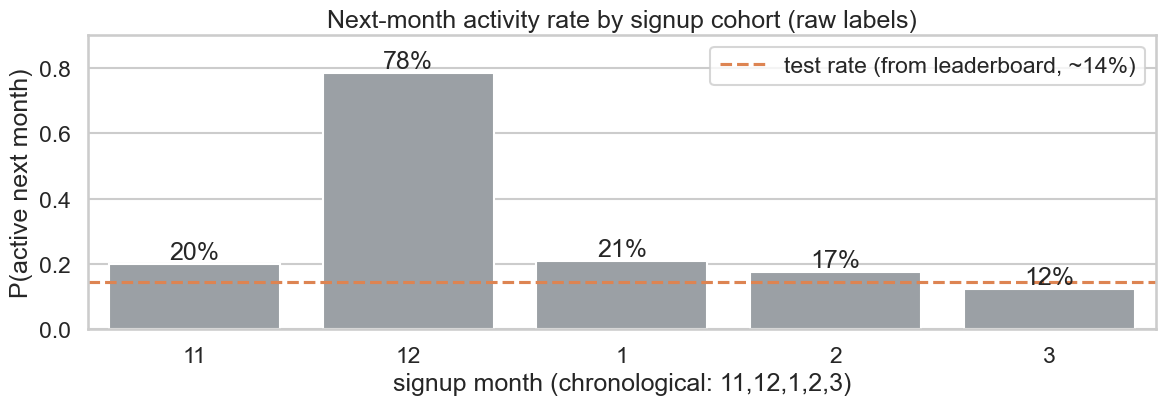

In [5]:
t_to_month = {0: 11, 1: 12, 2: 1, 3: 2, 4: 3}
d = pd.DataFrame({"cohort": X.index.get_level_values("t").map(t_to_month), "y": y.values})
order = [11, 12, 1, 2, 3]
fig, ax = plt.subplots(figsize=(12, 4.4))
sns.barplot(data=d, x="cohort", y="y", order=order, color="#9aa0a6", errorbar=None, ax=ax)
ax.axhline(0.143, color="C1", ls="--", label="test rate (from leaderboard, ~14%)")
for p in ax.patches: ax.annotate(f"{p.get_height():.0%}", (p.get_x()+p.get_width()/2, p.get_height()), ha="center", va="bottom")
ax.set(xlabel="signup month (chronological: 11,12,1,2,3)", ylabel="P(active next month)", title="Next-month activity rate by signup cohort (raw labels)", ylim=(0, 0.9))
ax.legend(); plt.tight_layout()

- M12 signups: **78 %** active vs 12–21 % elsewhere → all-ones F1 was 0.47 in CV but **0.25 on the leaderboard**.
- Something in M12's *label month* inflates the label.

## 4 · EDA (2): one system event poisons the target

**Speaker notes:** (4:20-5:20) 96 percent of the active M12 users have badge_OCZE; half of M12 has only that one record; it appears on a single day for 3000 users, so it looks like a bulk system grant, not user behaviour. We drop it at load time. This is a data-cleaning step motivated by EDA.

badge_OCZE: 8,864 rows, 8,489 users
Day-of-month distribution of badge_OCZE (top):
datetime Day_of_month
15    3219
29     287
4      250


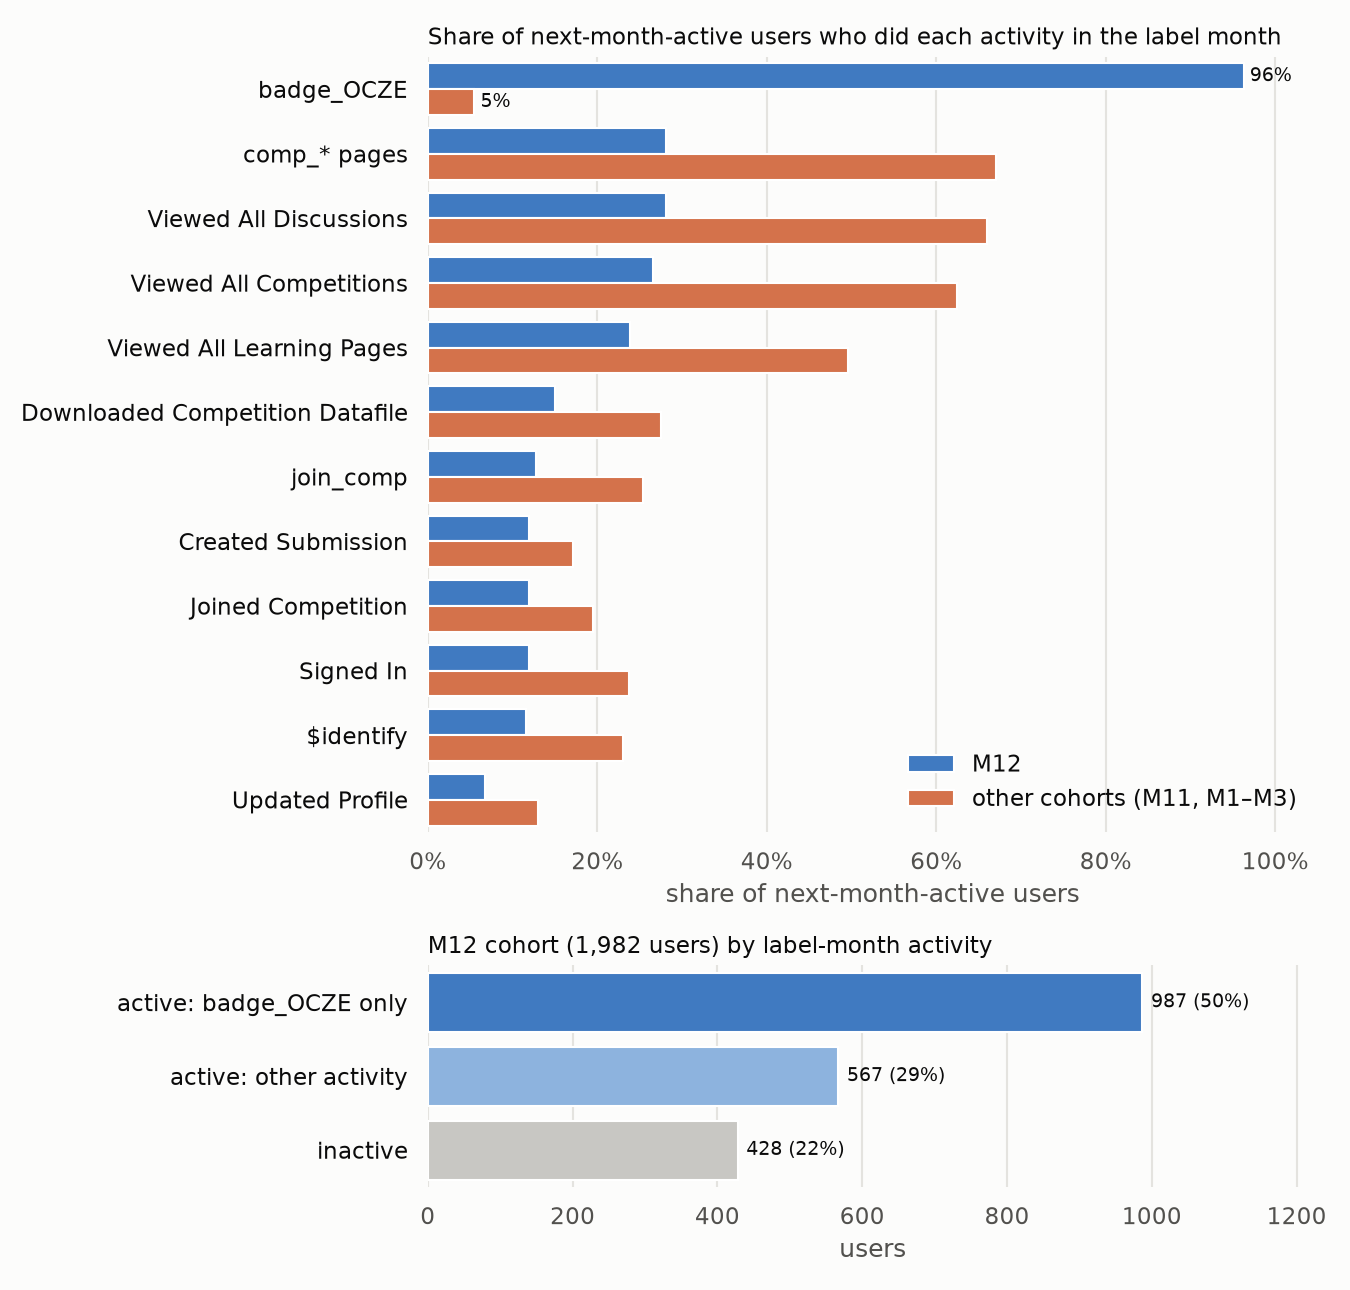

In [6]:
act = raw.activity
ev_by_title = act.groupby("Title").agg(rows=("User_ID","size"), users=("User_ID","nunique")).sort_values("rows", ascending=False)
badge = act[act.Title == "badge_OCZE"]
print(f"badge_OCZE: {len(badge):,} rows, {badge.User_ID.nunique():,} users")
print("Day-of-month distribution of badge_OCZE (top):"); print(badge["datetime Day_of_month"].value_counts().head(3).to_string())
display(Image(str(ROOT/"outputs"/"m12_label_activity.png"), width=1000))

## 4 · EDA (3): fix, verify, and re-check class balance

**Speaker notes:** (5:20-6:00) After removing the badge, December falls to 29 percent and all-ones CV F1 drops from 0.47 to 0.33, close to the leaderboard. Class balance becomes about 1 to 4, which motivates class weights.

All-ones F1 implied by positive rate: raw 0.468 -> clean 0.328  (leaderboard: 0.25)


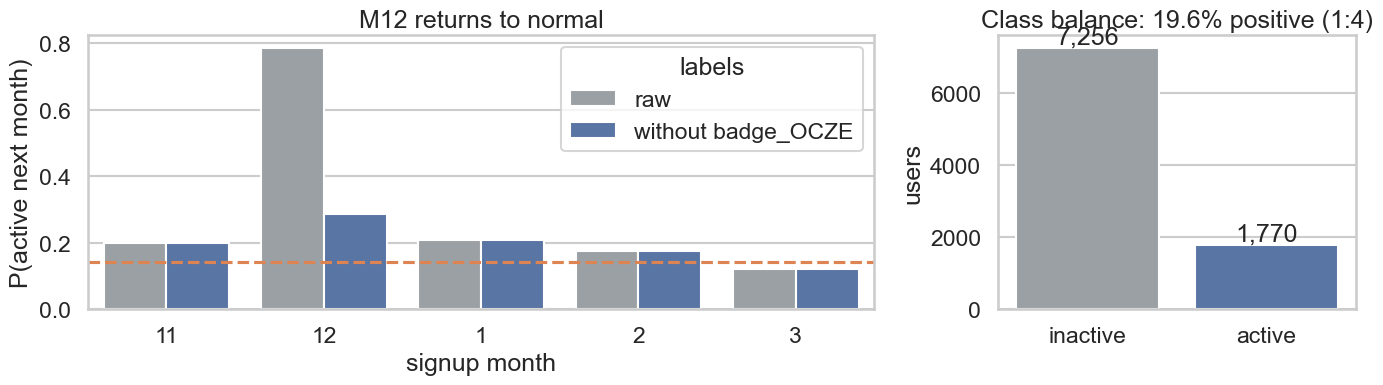

In [7]:
raw_c = load_raw()                                   # default drops badge_OCZE
xy = build_xy(raw_c, DatasetSpec(feature_groups=("profile", "activity_counts")))
Xc, yc = xy.X[xy.labelled], xy.y[xy.labelled].astype(int)
dc = pd.DataFrame({"cohort": Xc.index.get_level_values("t").map(t_to_month), "y": yc.values})
both = pd.concat([d.assign(labels="raw"), dc.assign(labels="without badge_OCZE")])
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw={"width_ratios": [2.2, 1]})
sns.barplot(data=both, x="cohort", y="y", hue="labels", order=order, palette=["#9aa0a6", "C0"], errorbar=None, ax=axes[0])
axes[0].axhline(0.143, color="C1", ls="--"); axes[0].set(ylabel="P(active next month)", xlabel="signup month", title="M12 returns to normal")
cnt = yc.value_counts().rename({0: "inactive", 1: "active"})
sns.barplot(x=cnt.index, y=cnt.values, palette=["#9aa0a6", "C0"], ax=axes[1])
for p in axes[1].patches: axes[1].annotate(f"{int(p.get_height()):,}", (p.get_x()+p.get_width()/2, p.get_height()), ha="center", va="bottom")
axes[1].set(title=f"Class balance: {yc.mean():.1%} positive (1:4)", ylabel="users", xlabel="")
plt.tight_layout()
print(f"All-ones F1 implied by positive rate: raw {2*y.mean()/(1+y.mean()):.3f} -> clean {2*yc.mean()/(1+yc.mean()):.3f}  (leaderboard: 0.25)")

## 4 · EDA (4): which behaviours predict retention?

**Speaker notes:** (6:00-6:50) Show that engaged users - those who browse competitions, join, download data - retain much more than the 20 percent base rate. Missing country and profile features carry little signal. This tells us a simple, count-based model is reasonable and which features matter.

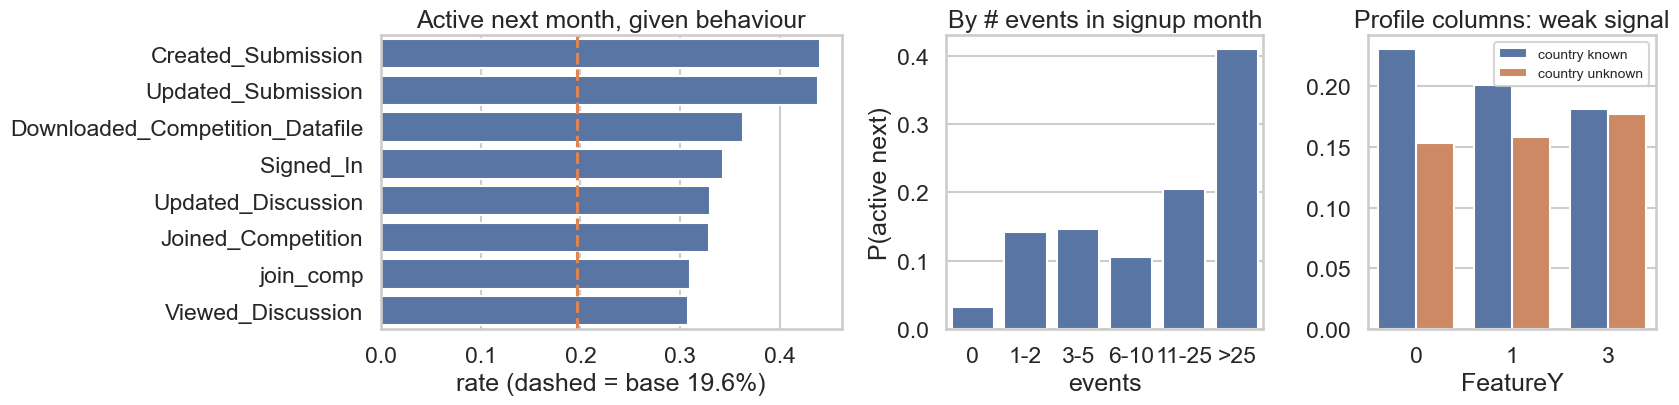

In [8]:
acts = Xc.filter(like="act_")
rate = {c: yc[acts[c] > 0].mean() for c in acts.columns if (acts[c] > 0).sum() >= 150}
share = {c: (acts[c] > 0).mean() for c in rate}
top = pd.DataFrame({"P(active next | did it)": rate, "share of users": share}).sort_values("P(active next | did it)", ascending=False)
top = top[~top.index.str.contains("ID_")].head(8)           # generic behaviours only
n_events = acts.sum(axis=1)
bins = pd.cut(n_events, [-1, 0, 2, 5, 10, 25, 1e9], labels=["0", "1-2", "3-5", "6-10", "11-25", ">25"])
fig, axes = plt.subplots(1, 3, figsize=(17, 4.4), gridspec_kw={"width_ratios": [1.6, 1.1, 1]})
sns.barplot(y=top.index.str.replace("act_", ""), x=top.iloc[:, 0], color="C0", ax=axes[0]); axes[0].axvline(yc.mean(), color="C1", ls="--"); axes[0].set(title="Active next month, given behaviour", xlabel="rate (dashed = base 19.6%)", ylabel="")
sns.barplot(x=bins, y=yc.groupby(bins).transform("mean").values*0+yc.values, color="C0", errorbar=None, ax=axes[1]); axes[1].set(title="By # events in signup month", xlabel="events", ylabel="P(active next)")
cat = pd.concat([Xc.FeatureY.astype(str).rename("FeatureY"), Xc.Countries_ID.isna().map({True: "country unknown", False: "country known"}).rename("c")], axis=1).assign(y=yc.values)
sns.barplot(data=cat, x="FeatureY", y="y", hue="c", errorbar=None, ax=axes[2]); axes[2].set(title="Profile columns: weak signal", ylabel=""); axes[2].legend(title="", fontsize=10, loc="upper right")
plt.tight_layout()

**Findings:** activity volume is the strongest signal (heavy users >25 events: 41 % vs 3 % with none); profile columns and missing country barely matter → keep them, but rely on behaviour counts.

## 4 · EDA (5): per-page features do not transfer to new months

**Speaker notes:** (6:50-7:30) Competitions and blogs change every month. 29 percent of April competition views land on columns the training data never saw. So we also build page-type features: 45 columns instead of 390, and 100 percent of test views fall on well-supported columns.

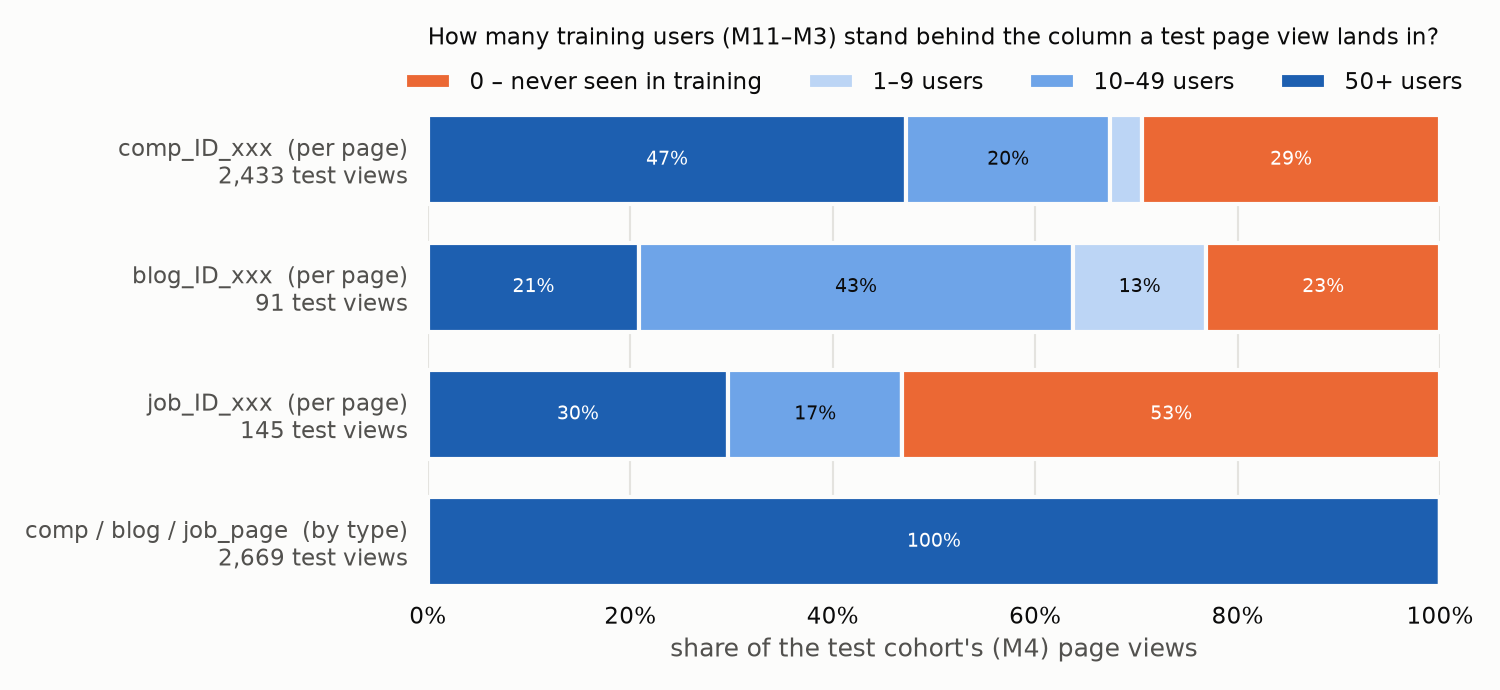

per-page features: 390 columns  ->  per-type features: 45 columns


In [9]:
display(Image(str(ROOT/"outputs"/"page_support.png"), width=1000))
xy_t = build_xy(raw_c, DatasetSpec(feature_groups=("profile", "activity_counts_by_type")))
print("per-page features:", xy.X.shape[1], "columns  ->  per-type features:", xy_t.X.shape[1], "columns")

## 5 · Evaluation design

- **Metric: F1 of the positive class** – the competition metric; with 1 : 4 imbalance, accuracy would reward "everyone inactive". Reference = all-ones (F1 = 2p/(1+p) = **0.328**).
- **Cross-validation:** 5-fold, **stratified by label, grouped by user**, one fixed seed → every model sees the *same* folds.
- **Hyper-parameters:** grid of **216** decision-tree settings (depth, leaf size, criterion, class weight), scored by F1.
- **Nested CV:** the grid search runs *inside* each outer training fold, so the validation score is not inflated by tuning.
- Threshold fixed at 0.5 (no tuning) so experiments are comparable.

**Speaker notes:** (7:30-8:20) Explain why F1, why stratified, why nested. Both are motivated by the data: imbalance and the need to avoid optimistic tuning.

In [10]:
folds = kfold_by_user(xy, 5)
print(pd.DataFrame({"fold": [f.k for f in folds],
                    "n_valid": [len(f.valid_index) for f in folds],
                    "pos_rate": [xy.y.loc[f.valid_index].mean() for f in folds]}).round(3).to_string(index=False))

 fold  n_valid  pos_rate
    0     1806     0.203
    1     1805     0.193
    2     1805     0.200
    3     1805     0.203
    4     1805     0.182


## 6 · Models, tuning and results

**Speaker notes:** (8:20-9:20) Read the table: class weighting lifted logistic regression from 0.375 to 0.475; tuning removed the tree's overfit (0.995 train to 0.391 validation, versus 0.456); page-type features gave 0.469 with a much shallower tree. Everything beats the 0.328 baseline.

In [11]:
from sklearn.metrics import precision_score, recall_score
from src.eval.metrics import f1
from src.models import make_all_ones, make_logreg, make_tree

def oof(factory, xyd):
    pred = pd.Series(index=xyd.y[xyd.labelled].index, dtype=float); scores = []
    for f in folds:
        Xt, yt = f.train(xyd); Xv, yv = f.valid(xyd)
        p = pd.Series(factory().fit(Xt, yt).predict(Xv), index=yv.index); pred.loc[yv.index] = p; scores.append(f1(yv, p))
    return pred.astype(int), np.array(scores)

Xl = xy.X[xy.labelled]; Xl_t = xy_t.X[xy_t.labelled]
best = dict(max_depth=5, min_samples_leaf=1, criterion="gini", class_weight="balanced")   # chosen by 216-point nested search
runs = {
  "All ones (baseline)":              (make_all_ones, xy),
  "LogReg":                           (lambda: make_logreg(Xl), xy),
  "LogReg + class weights":           (lambda: make_logreg(Xl, class_weight="balanced"), xy),
  "Decision tree (default)":          (lambda: make_tree(Xl), xy),
  "Tuned tree, per-type features":    (lambda: make_tree(Xl_t, **best), xy_t),
}
rows, preds = [], {}
for name, (fac, d) in runs.items():
    p, s = oof(fac, d); preds[name] = p; yv = d.y[d.labelled].astype(int)
    rows.append({"model": name, "F1 mean": s.mean(), "F1 std": s.std(), "precision": precision_score(yv, p), "recall": recall_score(yv, p), "% flagged": p.mean()})
res = pd.DataFrame(rows).set_index("model").round(3); res

,F1 mean,F1 std,precision,recall,% flagged
model,,,,,
All ones (baseline),0.328,0.011,0.196,1.000,1.000
LogReg,0.372,0.023,0.596,0.271,0.089
LogReg + class weights,0.474,0.007,0.389,0.608,0.307
Decision tree (default),0.374,0.024,0.372,0.376,0.198
"Tuned tree, per-type features",0.466,0.014,0.351,0.695,0.388


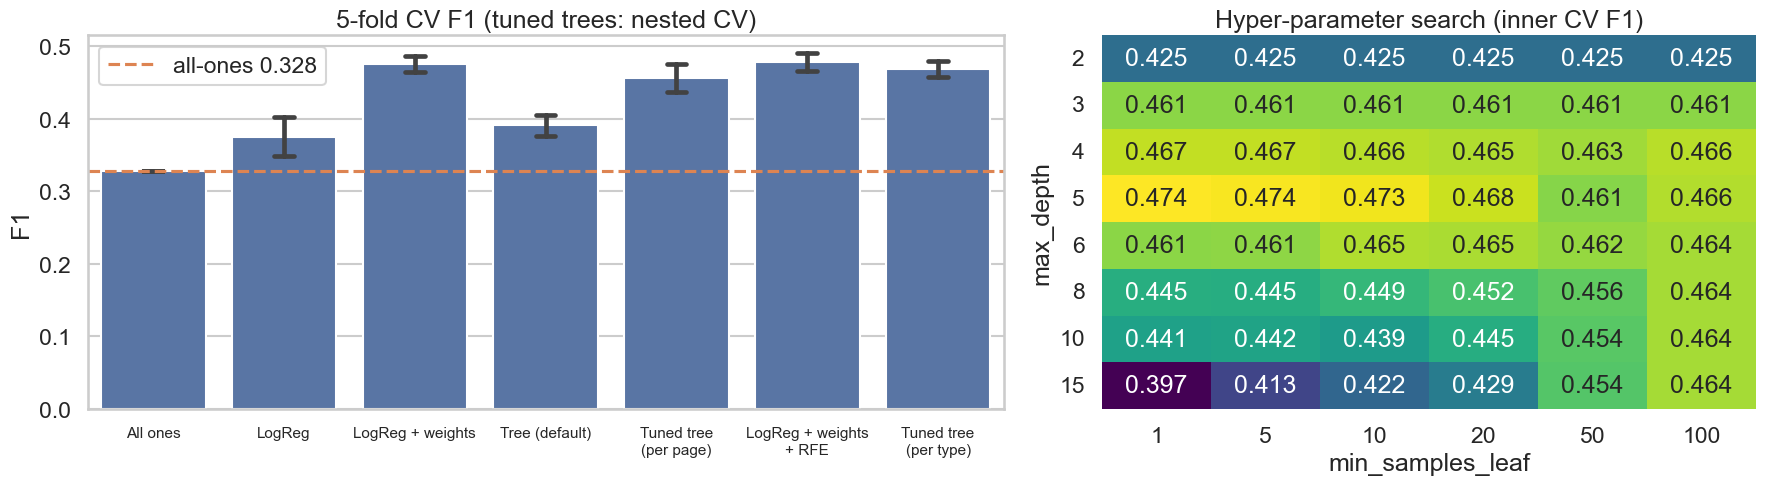

In [12]:
nested = pd.read_csv(ROOT/"outputs"/"cv_scores.csv")
nested = nested[nested.model.str.contains("no badge|all_ones \\[no")]
nested["model"] = nested.model.replace({
  "all_ones [no badge_OCZE]": "All ones", "logreg_per_page [no badge_OCZE]": "LogReg",
  "logreg_per_page_balanced [no badge_OCZE]": "LogReg + weights", "decision_tree [no badge_OCZE]": "Tree (default)",
  "decision_tree_tuned [no badge_OCZE]": "Tuned tree\n(per page)", "decision_tree_tuned [no badge_OCZE, by type]": "Tuned tree\n(per type)",
  "logreg_per_page_balanced_rfe [no badge_OCZE]": "LogReg + weights\n+ RFE"})
fig, axes = plt.subplots(1, 2, figsize=(18, 5.2), gridspec_kw={"width_ratios": [1.4, 1]})
sns.barplot(data=nested, x="model", y="F1", errorbar="sd", color="C0", capsize=.15, ax=axes[0])
axes[0].axhline(0.328, color="C1", ls="--", label="all-ones 0.328"); axes[0].legend(); axes[0].set(title="5-fold CV F1 (tuned trees: nested CV)", xlabel="")
plt.setp(axes[0].get_xticklabels(), rotation=0, fontsize=11)
ts = pd.read_csv(ROOT/"outputs"/"tree_search_no_badge_by_type.csv")
hm = ts[(ts.class_weight == "balanced") & (ts.criterion == "gini")].pivot_table(index="max_depth", columns="min_samples_leaf", values="F1_mean")
hm.index = [("None" if pd.isna(i) else str(int(i))) for i in hm.index]
sns.heatmap(hm, annot=True, fmt=".3f", cmap="viridis", ax=axes[1], cbar=False); axes[1].set(title="Hyper-parameter search (inner CV F1)", ylabel="max_depth"); axes[1].tick_params(axis="y", rotation=0)
plt.tight_layout()

## 7 · Analysis, real-world use and impact

**Speaker notes:** (9:20-10:00) Conclude: the model beats the baseline, but precision around 0.4 means it is a targeting aid, not an oracle. Compute lift and the simple campaign example. Biggest lesson: the label problem mattered more than the model. Limitations: random split, fixed threshold, leaderboard pending.

In [13]:
base = yc.mean()
r = res.loc["LogReg + class weights"]; t = res.loc["Tuned tree, per-type features"]
print(f"Base rate {base:.1%}. LogReg+weights: flags {r['% flagged']:.0%}, precision {r['precision']:.0%} (lift x{r['precision']/base:.1f}), recall {r['recall']:.0%}")
# Toy campaign: 10,000 new users, a $1 re-engagement nudge per user.
N, cost = 10_000, 1.0
for name, row in [("Nudge everyone", dict(precision=base, recall=1.0, **{"% flagged": 1.0})), ("Nudge model's picks", r)]:
    sent = N*row["% flagged"]; reached_retainable = sent*row["precision"]
    print(f"{name:20s}: {sent:6.0f} msgs, ${sent*cost:6.0f}, actives reached {reached_retainable:5.0f}, ${sent*cost/reached_retainable:.2f} per active")

Base rate 19.6%. LogReg+weights: flags 31%, precision 39% (lift x2.0), recall 61%
Nudge everyone      :  10000 msgs, $ 10000, actives reached  1961, $5.10 per active
Nudge model's picks :   3070 msgs, $  3070, actives reached  1194, $2.57 per active


**Takeaways**
- **Best models:** weighted LogReg **F1 0.475**, tuned per-type tree **0.469** (vs all-ones 0.328, +0.14).
- Biggest wins came from **data understanding**, not model choice: removing the `badge_OCZE` leak (label bias), class weights (+0.10), controlling tree depth (+0.065).
- **Applicability:** precision ≈ 0.3–0.4 – good for *prioritising* cheap nudges (≈2× lift), not for costly or irreversible actions.
- **Impact (toy):** same actives reached with fewer messages → lower cost per retained user.

**Does it solve the problem?** Partly: it ranks users usefully, but absolute accuracy is modest; a month of signup behaviour is a limited signal.

**Limitations / next:** random-split CV mixes months → use time-based CV; tune the threshold; add richer features; confirm on the leaderboard.

# Thank you — Questions?
Code: `src/` (data, eval, models) · Report: `report/report.pdf` · Reproduce: `python scripts/run_cv.py`

**Speaker notes:** (10:00) Close and take questions.